In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

from collections import Counter
from wordcloud import WordCloud

In [3]:
# 엑셀파일 로드
df = pd.read_excel("news_2.xlsx")
df.head()

,키워드
0,"올가을,로맨스,김소현,책임집,케이팝,헌터스,케이팝,헌터스,주목,K팝,K드라마,K무비..."
1,"뉴스핌,마이,케이팝,스타,본선,라이브,시작,3일,10팀,공개,이지은,종합뉴스통신사,..."
2,"임정희,김보경,성료,합동,콘서트,히트곡,퍼레이드,공연,이지은,가수,임정희,김보경,합..."
3,"피프티피프티,엔터테크,GES,서울,홍보,대사,발탁,18일,위촉식,축하,무대,출격,피..."
4,"아이딧,의지,1주년,소감,팀명,세상,일문일답,그룹,아이딧,IDID,데뷔,소감,위딧,..."


In [4]:
keywords = df["키워드"] # df.loc[], df.iloc[], df[]
keywords.head()

0    올가을,로맨스,김소현,책임집,케이팝,헌터스,케이팝,헌터스,주목,K팝,K드라마,K무비...
1    뉴스핌,마이,케이팝,스타,본선,라이브,시작,3일,10팀,공개,이지은,종합뉴스통신사,...
2    임정희,김보경,성료,합동,콘서트,히트곡,퍼레이드,공연,이지은,가수,임정희,김보경,합...
3    피프티피프티,엔터테크,GES,서울,홍보,대사,발탁,18일,위촉식,축하,무대,출격,피...
4    아이딧,의지,1주년,소감,팀명,세상,일문일답,그룹,아이딧,IDID,데뷔,소감,위딧,...
Name: 키워드, dtype: str

In [5]:
# 키워드 컬럼값을 하나의 문자열로 통합
text = ",".join(keywords)
print("문자열의 길이: ", len(text)) # 문자열의 길이 563936
print(text[:500])

문자열의 길이:  563936
올가을,로맨스,김소현,책임집,케이팝,헌터스,케이팝,헌터스,주목,K팝,K드라마,K무비,K컬쳐,중심,별들,현장,사진,스타투데이,사진,뉴스레터,코너,드라마,연애,박사,배우,김소현,화이트,드레스,민트,스푼,청순,페미닌,정석,배우,김소현,성수동,행사,향수,브랜드,참석,미모,선사,이날,김소현,화이트,드레스,청순,분위기,완성,목선,홀터넥,스타일,화이트,원피스,취재진,심플,디자인,자연,플레어,실루엣,여성,분위기,어깨,라인,홀터넥,디자인,과도,노출,세련미,스타일링,포인트,스틸레토,민트,컬러,스틸레토,머리,발끝,화이트,통일,민트색,슈즈,매치,전체적,생기,화이트,파스텔,민트,조합,청량감,전체적,액세서리,최소화,귀걸이,반지,정도,생머리,자연,드레스,특유,분위기,미니멀,스타일링,드레스,실루엣,인물,분위기,강조,김소현,공개,드라마,연애,박사,시청자들,올가을,로맨스,배우,김소현,모습,사진,김소현,입장,순백,여신,김소현,미모,장인,올가을,예약,로맨스,장인,꽃받침,손인사,김소현,볼콕,매력,로맨스,비율,김소현,김소


In [ ]:
# 수치로 시각화 탐색을 위해
# text를 리스트로 변경
words = text.split(",")
print("리스트의 사이즈: ", len(words))
print(words[:30])

리스트의 사이즈:  150625
['올가을', '로맨스', '김소현', '책임집', '케이팝', '헌터스', '케이팝', '헌터스', '주목', 'K팝', 'K드라마', 'K무비', 'K컬쳐', '중심', '별들', '현장', '사진', '스타투데이', '사진', '뉴스레터', '코너', '드라마', '연애', '박사', '배우', '김소현', '화이트', '드레스', '민트', '스푼']


In [ ]:
# 리스트 안의 단어별 카운트

words_count = Counter(words)
print(words_count.most_common(20)) # 1등~20등

[('영화', 946), ('한국', 923), ('케이팝', 876), ('음악', 836), ('공연', 773), ('문화', 694), ('글로벌', 647), ('세계', 639), ('축제', 637), ('미국', 582), ('콘텐츠', 533), ('무대', 525), ('앨범', 510), ('차트', 457), ('참여', 455), ('대표', 446), ('진행', 438), ('영화제', 426), ('행사', 417), ('서울', 406)]


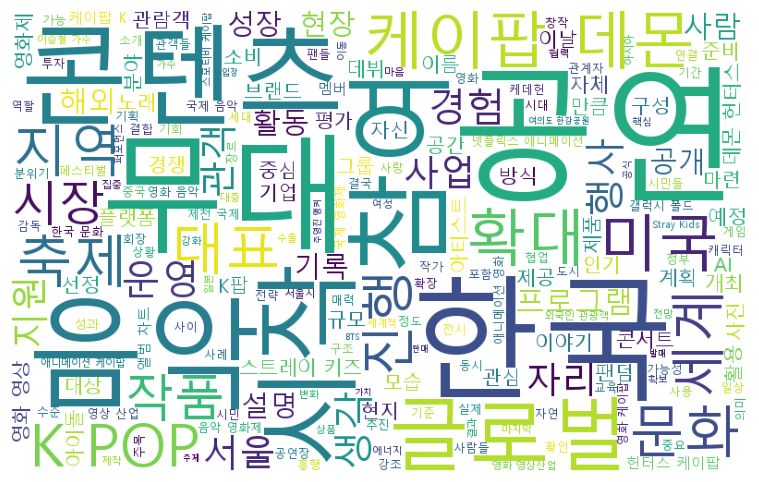

In [ ]:
# WordCloud 생성
wordcloud = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf", # WordCloud안에서 한글 깨짐 방지 - 한글 폰트 설정
    width=800,
    height=500,
    background_color="white",
    stopwords=set()
).generate(text)

# 출력
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

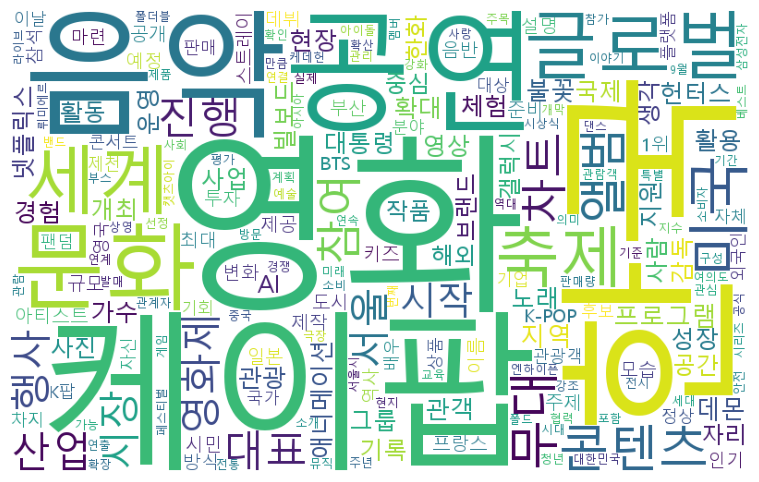

In [11]:
wordcloud2 = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf", # WordCloud안에서 한글 깨짐 방지 - 한글 폰트 설정
    width=800,
    height=500,
    background_color="white",
    stopwords=set()
).generate_from_frequencies(words_count)

# 출력
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud2)
plt.axis("off")
plt.show()